In [38]:
summary = pd.DataFrame({
    'Metric': [
        'Total Traffic Events',
        'Pageviews',
        'Clicks',
        'Previews',
        'Countries',
        'Cities',
        'Artists',
        'Tracks',
        'Links'
    ],
    'Value': [
        len(df),
        (df['event'] == 'pageview').sum(),
        (df['event'] == 'click').sum(),
        (df['event'] == 'preview').sum(),
        df['country'].nunique(),
        df['city'].nunique(),
        df['artist'].nunique(),
        df['track'].nunique(),
        df['linkid'].nunique()
    ]
})

display(summary)

,Metric,Value
0,Total Traffic Events,122567
1,Pageviews,73360
2,Clicks,32499
3,Previews,16708
4,Countries,212
5,Cities,11993
6,Artists,2420
7,Tracks,3563
8,Links,3839


In [37]:
df.to_csv(
    "Alfido_Tech_Website_Traffic_Cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


# Conclusion

The Website Traffic Analysis provided useful insights into website activity, including event types, daily traffic, geographic distribution, popular content, links and user engagement.

The analysis shows which countries, cities, artists, tracks and links generate the highest activity. These insights can help Alfido Tech improve content strategy, optimize user interactions, target high-performing markets and strengthen conversion opportunities.

Regular monitoring of traffic and engagement metrics can help Alfido Tech make data-driven decisions and continuously improve website performance.

# Recommendations for Alfido Tech

### 1. Optimize High-Traffic Pages
Identify the pages and links receiving the highest traffic and improve their calls-to-action to encourage more conversions.

### 2. Improve Click Engagement
Since clicks represent an important part of user activity, optimize buttons, links and interactive elements to encourage more users to take action.

### 3. Target High-Traffic Locations
Focus digital marketing campaigns and localized content on countries and cities generating the highest traffic.

### 4. Promote High-Performing Content
Use popular content and high-performing tracks/pages as a basis for future campaigns and recommendations.

### 5. Monitor Traffic Trends
Track daily traffic and event patterns regularly to identify changes in user engagement and measure the impact of website improvements.

In [36]:
print("KEY INSIGHTS")
print("=" * 60)

print(f"1. The dataset contains {len(df):,} traffic events.")
print(f"2. Pageviews are the most common event type with {event_counts.get('pageview', 0):,} events.")
print(f"3. {top_countries.index[0]} generated the highest traffic among countries.")
print(f"4. {top_cities.index[0]} generated the highest traffic among cities.")
print(f"5. {top_artists.index[0]} was the most interacted-with artist.")
print(f"6. {top_tracks.index[0]} was the most popular track.")
print(f"7. {top_links.index[0]} was the most active link.")

KEY INSIGHTS
1. The dataset contains 122,567 traffic events.
2. Pageviews are the most common event type with 73,360 events.
3. United States generated the highest traffic among countries.
4. Unknown generated the highest traffic among cities.
5. Tesher was the most interacted-with artist.
6. Jalebi Baby was the most popular track.
7. 2d896d31-97b6-4869-967b-1c5fb9cd4bb8 was the most active link.


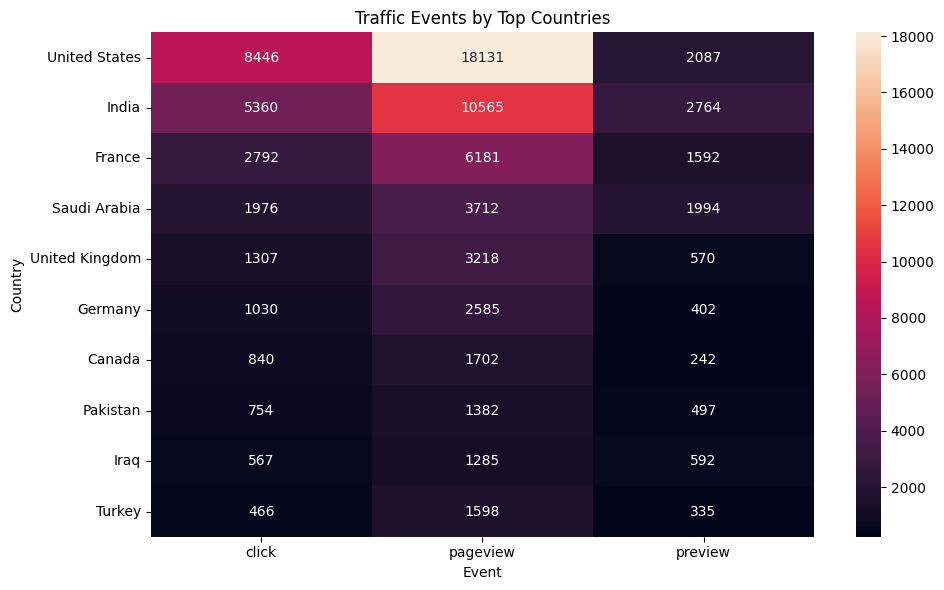

In [35]:
plt.figure(figsize=(10,6))

sns.heatmap(
    country_event.loc[top_country_names],
    annot=True,
    fmt='d'
)

plt.title("Traffic Events by Top Countries")
plt.xlabel("Event")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [34]:
country_event = pd.crosstab(
    df['country'].fillna('Unknown'),
    df['event']
)

top_country_names = (
    df['country']
    .fillna('Unknown')
    .value_counts()
    .head(10)
    .index
)

display(country_event.loc[top_country_names])

event,click,pageview,preview
country,,,
United States,8446,18131,2087
India,5360,10565,2764
France,2792,6181,1592
Saudi Arabia,1976,3712,1994
United Kingdom,1307,3218,570
Germany,1030,2585,402
Canada,840,1702,242
Pakistan,754,1382,497
Iraq,567,1285,592


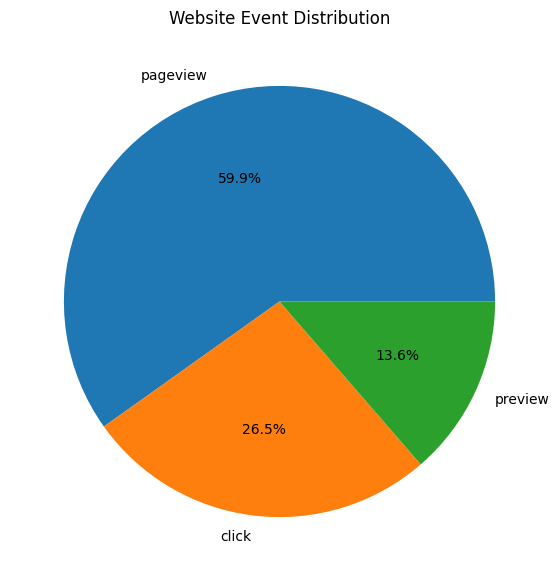

In [33]:
plt.figure(figsize=(7,7))

event_share.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Website Event Distribution")
plt.ylabel("")
plt.show()

In [32]:
event_share = (
    df['event']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Event Percentage:")
display(event_share)

Event Percentage:


,proportion
event,
pageview,59.85
click,26.52
preview,13.63


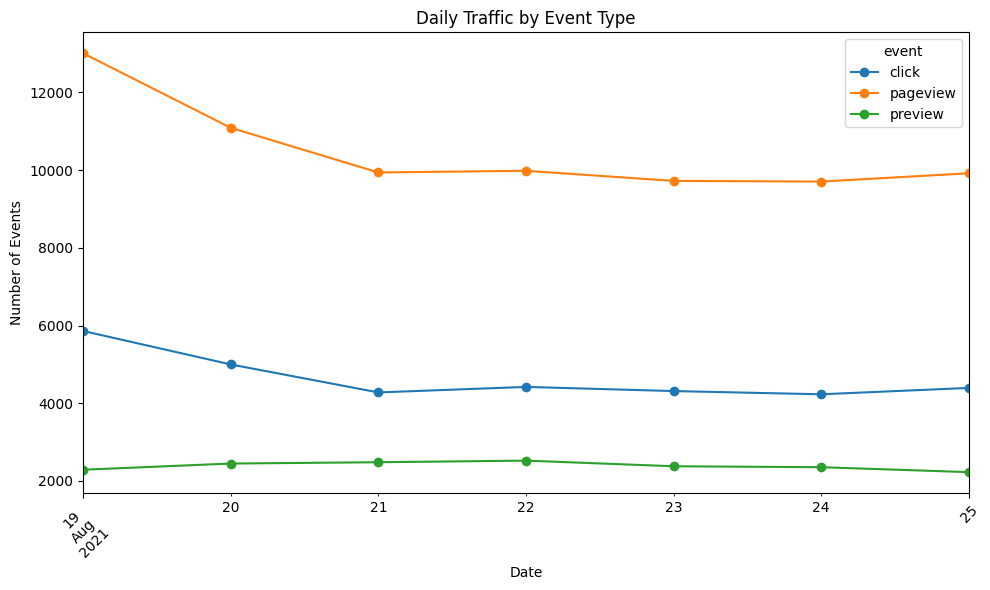

In [31]:
daily_events.plot(
    kind='line',
    marker='o',
    figsize=(10,6)
)

plt.title("Daily Traffic by Event Type")
plt.xlabel("Date")
plt.ylabel("Number of Events")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
daily_events = pd.crosstab(
    df['date'],
    df['event']
)

print("Daily Event Breakdown:")
display(daily_events)

Daily Event Breakdown:


event,click,pageview,preview
date,,,
2021-08-19,5860,13006,2290
2021-08-20,4999,11088,2449
2021-08-21,4279,9939,2483
2021-08-22,4421,9982,2524
2021-08-23,4314,9722,2379
2021-08-24,4231,9705,2355
2021-08-25,4395,9918,2228


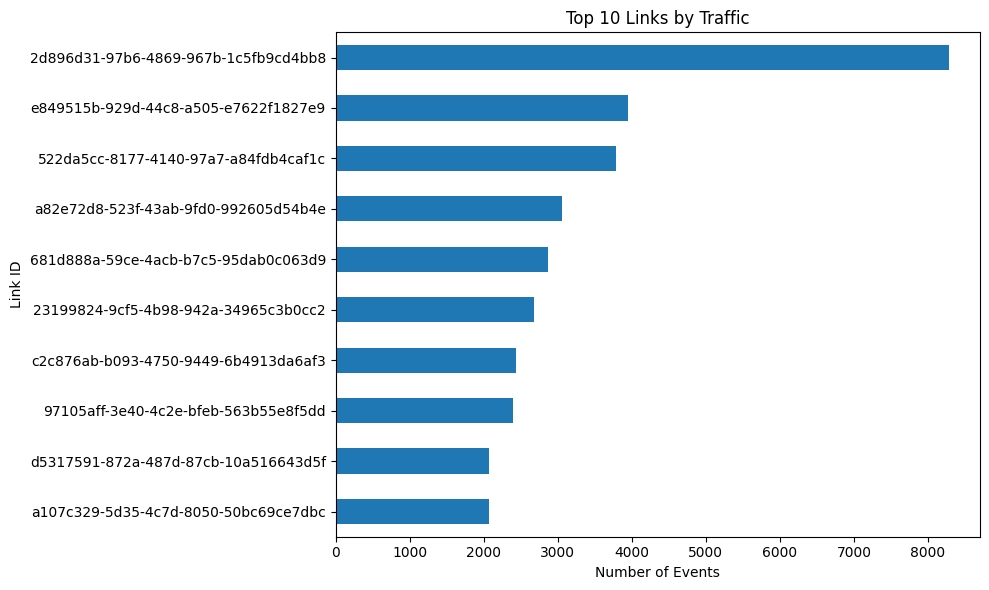

In [29]:
plt.figure(figsize=(10,6))

top_links.sort_values().plot(kind='barh')

plt.title("Top 10 Links by Traffic")
plt.xlabel("Number of Events")
plt.ylabel("Link ID")
plt.tight_layout()
plt.show()

In [28]:
top_links = df['linkid'].value_counts().head(10)

print("Top 10 Links:")
display(top_links)

Top 10 Links:


,count
linkid,
2d896d31-97b6-4869-967b-1c5fb9cd4bb8,8288
e849515b-929d-44c8-a505-e7622f1827e9,3950
522da5cc-8177-4140-97a7-a84fdb4caf1c,3786
a82e72d8-523f-43ab-9fd0-992605d54b4e,3059
681d888a-59ce-4acb-b7c5-95dab0c063d9,2865
23199824-9cf5-4b98-942a-34965c3b0cc2,2675
c2c876ab-b093-4750-9449-6b4913da6af3,2442
97105aff-3e40-4c2e-bfeb-563b55e8f5dd,2390
d5317591-872a-487d-87cb-10a516643d5f,2074


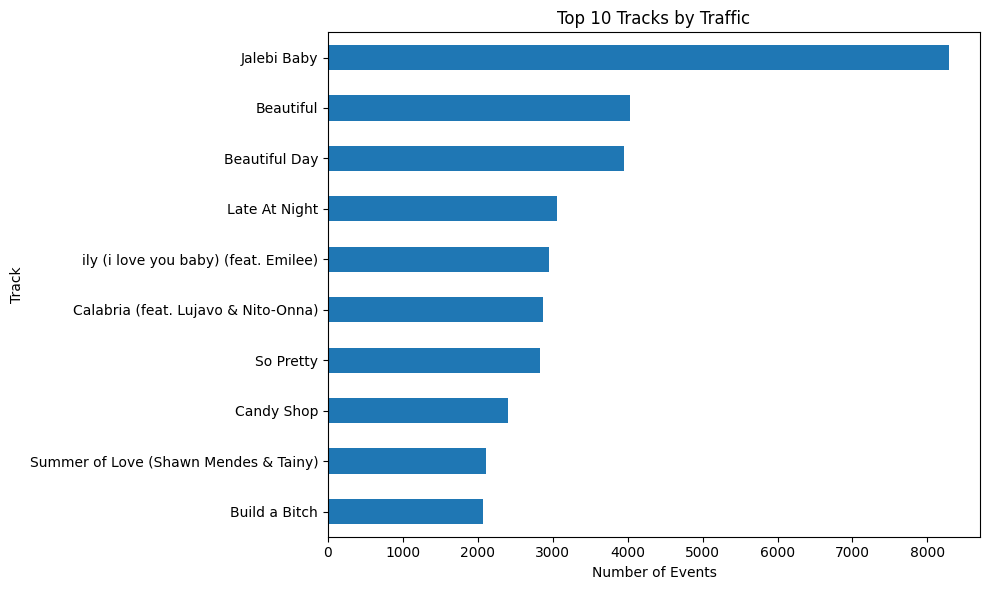

In [27]:
plt.figure(figsize=(10,6))

top_tracks.sort_values().plot(kind='barh')

plt.title("Top 10 Tracks by Traffic")
plt.xlabel("Number of Events")
plt.ylabel("Track")
plt.tight_layout()
plt.show()

In [26]:
top_tracks = (
    df['track']
    .fillna('Unknown')
    .value_counts()
    .head(10)
)

print("Top 10 Tracks:")
display(top_tracks)

Top 10 Tracks:


,count
track,
Jalebi Baby,8288
Beautiful,4037
Beautiful Day,3951
Late At Night,3059
ily (i love you baby) (feat. Emilee),2956
Calabria (feat. Lujavo & Nito-Onna),2865
So Pretty,2830
Candy Shop,2397
Summer of Love (Shawn Mendes & Tainy),2108


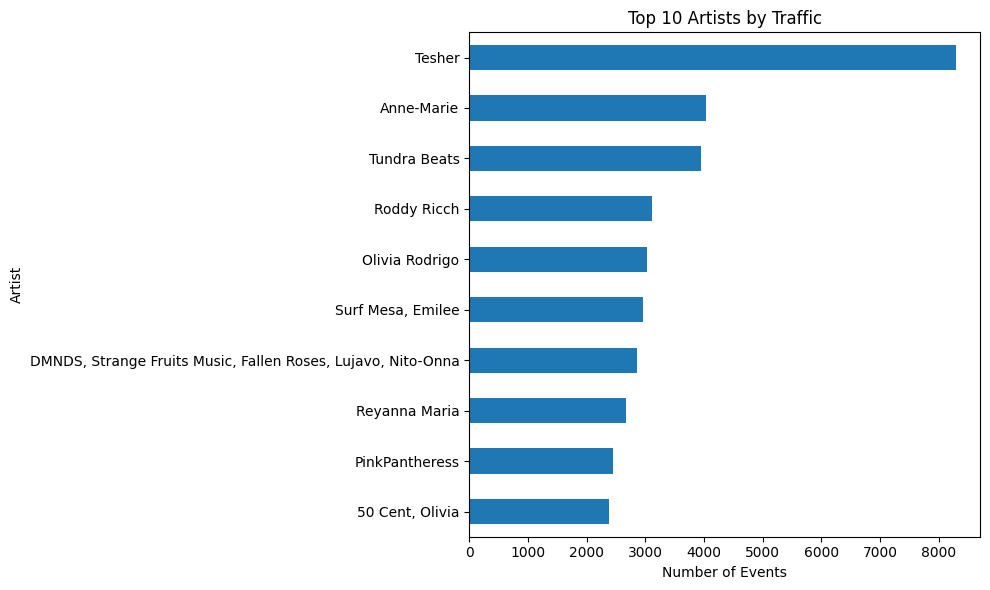

In [25]:
plt.figure(figsize=(10,6))

top_artists.sort_values().plot(kind='barh')

plt.title("Top 10 Artists by Traffic")
plt.xlabel("Number of Events")
plt.ylabel("Artist")
plt.tight_layout()
plt.show()

In [24]:
top_artists = (
    df['artist']
    .fillna('Unknown')
    .value_counts()
    .head(10)
)

print("Top 10 Artists:")
display(top_artists)

Top 10 Artists:


,count
artist,
Tesher,8288
Anne-Marie,4029
Tundra Beats,3951
Roddy Ricch,3107
Olivia Rodrigo,3037
"Surf Mesa, Emilee",2956
"DMNDS, Strange Fruits Music, Fallen Roses, Lujavo, Nito-Onna",2865
Reyanna Maria,2675
PinkPantheress,2446


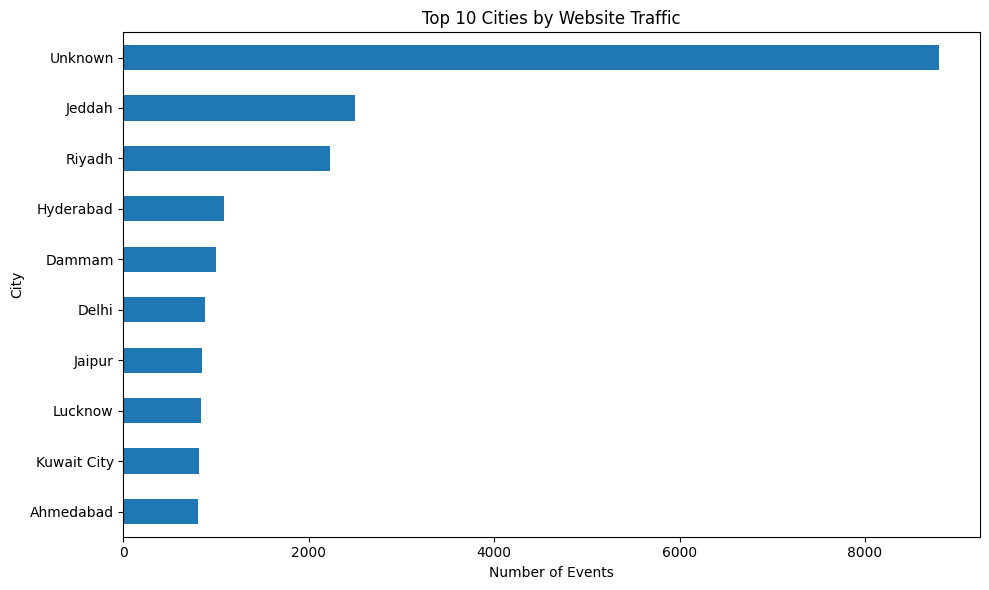

In [23]:
plt.figure(figsize=(10,6))

top_cities.sort_values().plot(kind='barh')

plt.title("Top 10 Cities by Website Traffic")
plt.xlabel("Number of Events")
plt.ylabel("City")
plt.tight_layout()
plt.show()

In [22]:
top_cities = df['city'].fillna('Unknown').value_counts().head(10)

print("Top 10 Cities:")
display(top_cities)

Top 10 Cities:


,count
city,
Unknown,8802
Jeddah,2497
Riyadh,2232
Hyderabad,1088
Dammam,1002
Delhi,884
Jaipur,849
Lucknow,837
Kuwait City,816


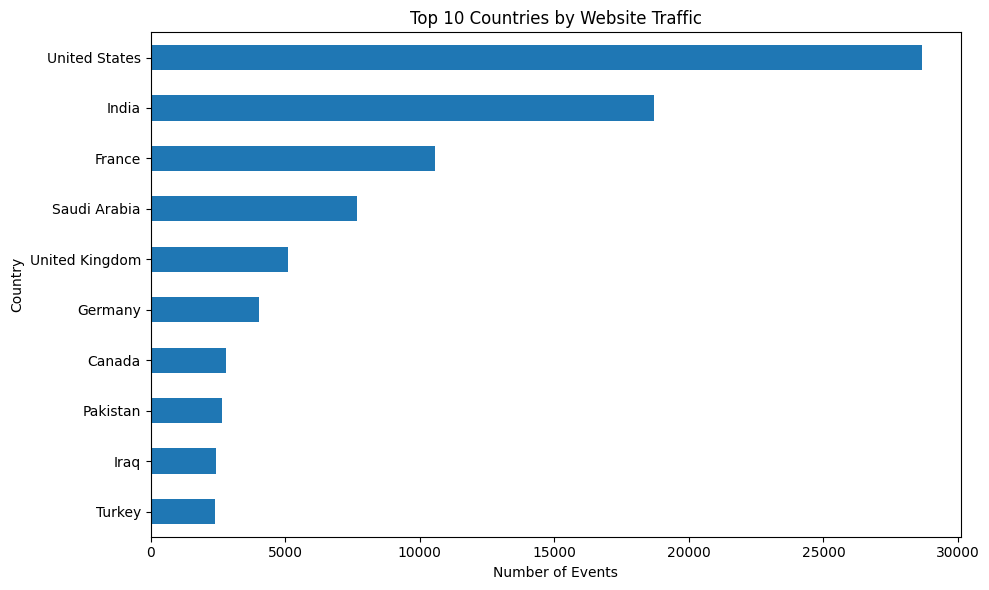

In [21]:
plt.figure(figsize=(10,6))

top_countries.sort_values().plot(kind='barh')

plt.title("Top 10 Countries by Website Traffic")
plt.xlabel("Number of Events")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [20]:
top_countries = df['country'].fillna('Unknown').value_counts().head(10)

print("Top 10 Countries:")
display(top_countries)

Top 10 Countries:


,count
country,
United States,28664
India,18689
France,10565
Saudi Arabia,7682
United Kingdom,5095
Germany,4017
Canada,2784
Pakistan,2633
Iraq,2444


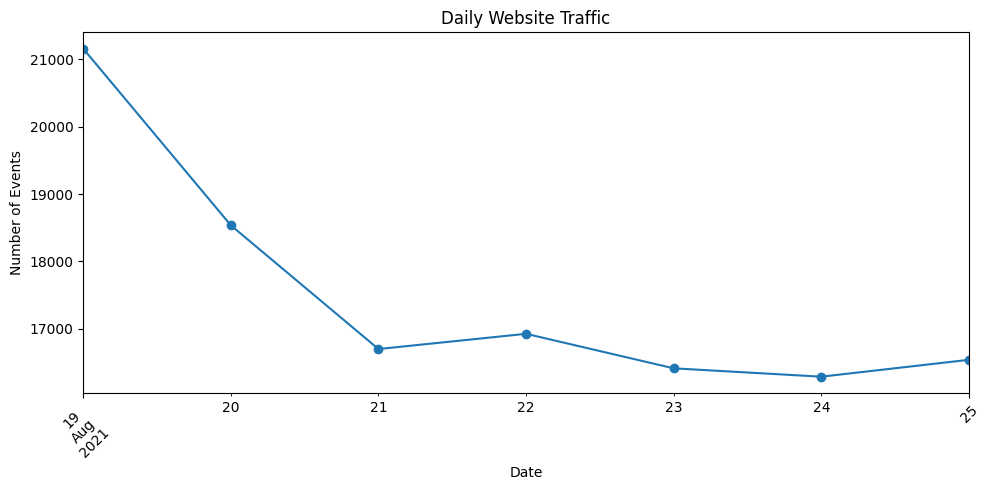

In [19]:
plt.figure(figsize=(10,5))

daily_traffic.plot(marker='o')

plt.title("Daily Website Traffic")
plt.xlabel("Date")
plt.ylabel("Number of Events")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
daily_traffic = df.groupby('date').size()

print("Daily Traffic:")
display(daily_traffic)

Daily Traffic:


,0
date,
2021-08-19,21156
2021-08-20,18536
2021-08-21,16701
2021-08-22,16927
2021-08-23,16415
2021-08-24,16291
2021-08-25,16541


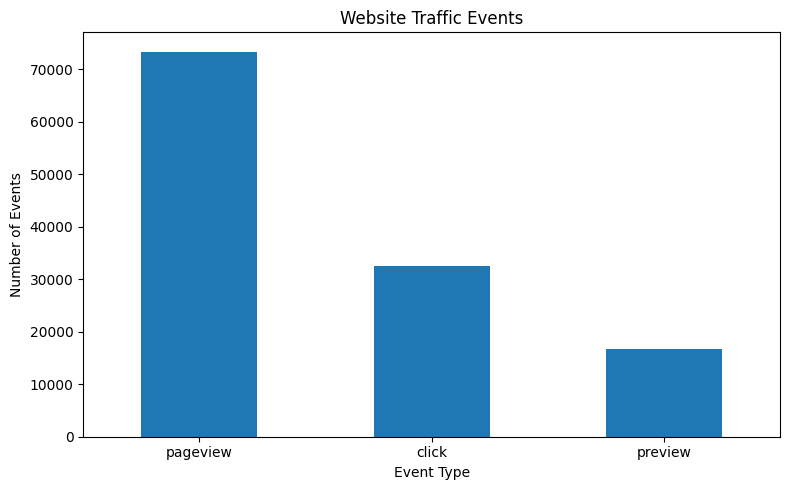

In [17]:
plt.figure(figsize=(8,5))
event_counts.plot(kind='bar')
plt.title("Website Traffic Events")
plt.xlabel("Event Type")
plt.ylabel("Number of Events")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
event_counts = df['event'].value_counts()

print("Event Distribution:")
display(event_counts)

Event Distribution:


,count
event,
pageview,73360
click,32499
preview,16708


In [13]:
print("Number of records:", len(df))
print("Number of countries:", df['country'].nunique())
print("Number of cities:", df['city'].nunique())
print("Number of artists:", df['artist'].nunique())
print("Number of tracks:", df['track'].nunique())
print("Number of links:", df['linkid'].nunique())

Number of records: 122567
Number of countries: 212
Number of cities: 11993
Number of artists: 2420
Number of tracks: 3563
Number of links: 3839


In [12]:
df['date'] = pd.to_datetime(df['date'])

print("Date conversion completed.")
print("Date range:", df['date'].min(), "to", df['date'].max())

Date conversion completed.
Date range: 2021-08-19 00:00:00 to 2021-08-25 00:00:00


In [11]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("\nCleaned dataset shape:", df.shape)

Missing values: 0
Duplicate rows: 0

Cleaned dataset shape: (122567, 9)


In [10]:
df = df.drop_duplicates().copy()

print("Duplicates removed successfully.")
print("New dataset shape:", df.shape)
print("Remaining duplicates:", df.duplicated().sum())

Duplicates removed successfully.
New dataset shape: (122567, 9)
Remaining duplicates: 0


In [9]:
# Check duplicate records

duplicate_rows = df[df.duplicated(keep=False)]

print("Total duplicate rows:", len(duplicate_rows))
print("Percentage of duplicate rows:",
      round(len(duplicate_rows) / len(df) * 100, 2), "%")

display(duplicate_rows.head(10))

Total duplicate rows: 131849
Percentage of duplicate rows: 58.27 %


,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
8,click,2021-08-21,United States,Pflugerville,Billie Eilish,Happier Than Ever,Happier Than Ever,USUM72105936,d58a7ad8-f1f7-43c7-90fc-02906b703089
9,click,2021-08-21,France,Unknown,"DMNDS, Strange Fruits Music, Fallen Roses, Luj...",Calabria (feat. Lujavo & Nito-Onna),Calabria (feat. Lujavo & Nito-Onna),GBSMU9833211,681d888a-59ce-4acb-b7c5-95dab0c063d9
10,click,2021-08-20,Sweden,Stockholm,Vitamin A,Happy Birthday,Happy Birthday,US3DF1612162,f563adc4-d7c6-4d70-93d0-06bab552f642
12,click,2021-08-20,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
14,click,2021-08-20,Saudi Arabia,Riyadh,Anne-Marie,Beautiful,Beautiful,GBAHS2100225,522da5cc-8177-4140-97a7-a84fdb4caf1c
15,click,2021-08-20,Qatar,Doha,"Lola Indigo, TINI, Belinda",La Niña,La Niña de la Escuela,ES5702100732,7c8bbf79-21c7-4b33-acaf-c8bf5a45c333


In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 103711


In [7]:
# Handle missing values

df['country'] = df['country'].fillna('Unknown')
df['city'] = df['city'].fillna('Unknown')
df['artist'] = df['artist'].fillna('Unknown')
df['album'] = df['album'].fillna('Unknown')
df['track'] = df['track'].fillna('Unknown')
df['isrc'] = df['isrc'].fillna('Unknown')

print("Missing values handled successfully.")

print("\nRemaining missing values:")
print(df.isnull().sum().sum())

Missing values handled successfully.

Remaining missing values:
0


In [6]:
missing = df.isnull().sum()

print("Missing values:")
display(missing[missing > 0])

Missing values:


,0
country,11
city,11
artist,37
album,5
track,5
isrc,7121


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226278 entries, 0 to 226277
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   event    226278 non-null  object
 1   date     226278 non-null  object
 2   country  226267 non-null  object
 3   city     226267 non-null  object
 4   artist   226241 non-null  object
 5   album    226273 non-null  object
 6   track    226273 non-null  object
 7   isrc     219157 non-null  object
 8   linkid   226278 non-null  object
dtypes: object(9)
memory usage: 15.5+ MB


In [4]:
display(df.head())

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [3]:
from google.colab import files
files.upload()
df = pd.read_csv("traffic.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Saving traffic.csv to traffic.csv
Dataset loaded successfully!
Shape: (226278, 9)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


# Website Traffic Analysis

### Alfido Tech – Data Analyst Internship

**Objective:**  
Analyze website traffic data to understand user activity, traffic patterns, popular content, geographic distribution and engagement events.

**Dataset:** Website Traffic Analysis

**Tools:** Python, Pandas, Matplotlib, Seaborn